=== ADVANCED AUDIO CLASSIFICATION WITH DEEP LEARNING ===
COLLECTING ADVANCED DATASET
Classes: ['audioanjing', 'audiobabi', 'audiobajingan', 'audiobangsat', 'audiogoblok', 'audiojancuk', 'audiotai', 'audiotolol']

Processing: audioanjing
   Found 25 files
   [1/20] anjing1.wav
ERROR anjing1.wav: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (183,) + inhomogeneous part.
   [2/20] anjing13.wav
ERROR anjing13.wav: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (183,) + inhomogeneous part.
   [3/20] anjing14.wav
ERROR anjing14.wav: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (183,) + inhomogeneous part.
   [4/20] anjing15.wav
ERROR anjing15.wav: setting an array element with a sequence. The requested array has an inhomogeneous shape aft

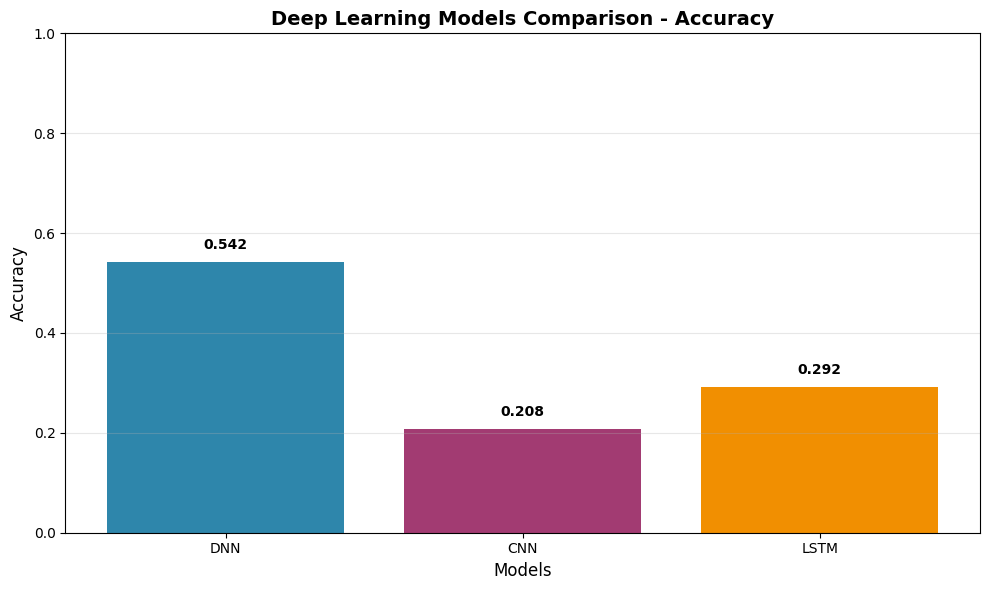

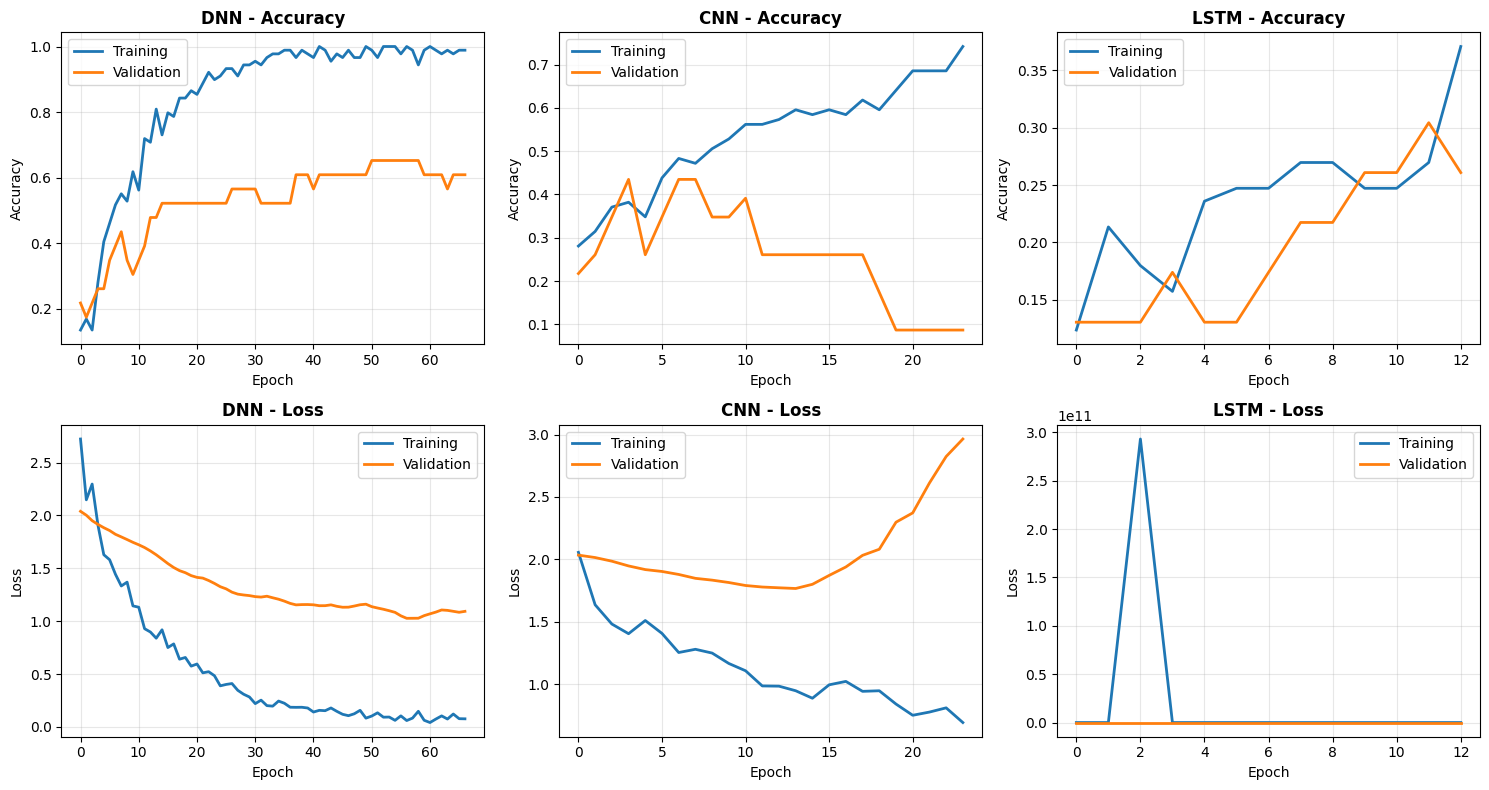

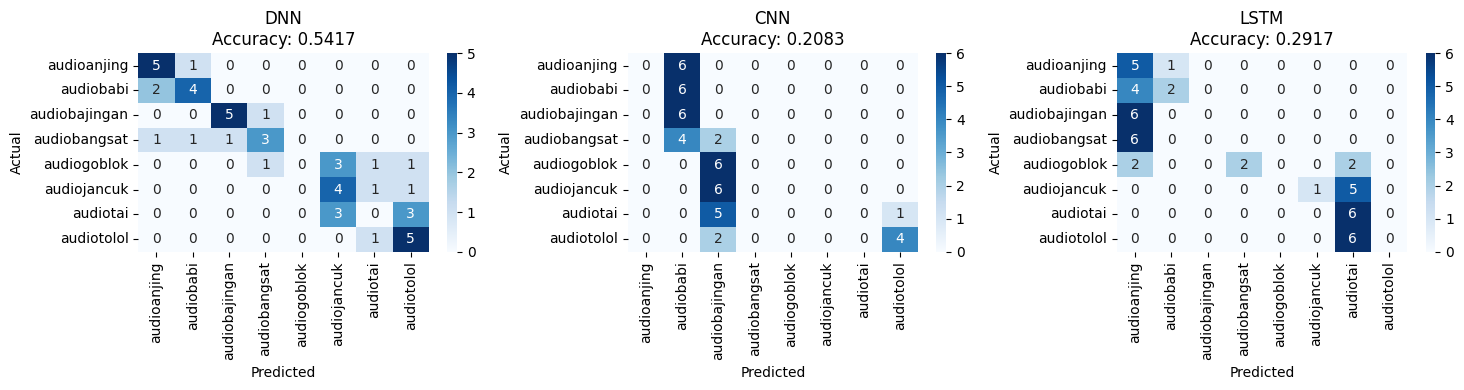


DETAILED CLASSIFICATION REPORT - DNN:
               precision    recall  f1-score   support

  audioanjing     0.6250    0.8333    0.7143         6
    audiobabi     0.6667    0.6667    0.6667         6
audiobajingan     0.8333    0.8333    0.8333         6
 audiobangsat     0.6000    0.5000    0.5455         6
  audiogoblok     0.0000    0.0000    0.0000         6
  audiojancuk     0.4000    0.6667    0.5000         6
     audiotai     0.0000    0.0000    0.0000         6
   audiotolol     0.5000    0.8333    0.6250         6

     accuracy                         0.5417        48
    macro avg     0.4531    0.5417    0.4856        48
 weighted avg     0.4531    0.5417    0.4856        48


FINAL ANALYSIS
MODERATE: Accuracy: 0.5417
Consider more data or feature engineering

Details:
   Best Model: <Sequential name=sequential, built=True>
   Total Samples: 160
   Features: 158
   Classes: 8


In [2]:
# =========================
# ADVANCED AUDIO CLASSIFICATION WITH DEEP LEARNING
# =========================
import os
import numpy as np
import librosa
import librosa.display
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler  # Added StandardScaler import
import seaborn as sns
import tensorflow as tf
import tensorflow.keras as keras
from tensorflow.keras import layers, Sequential
from tensorflow.keras.callbacks import EarlyStopping

# Set random seeds untuk reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ---------- Konfigurasi ----------
DATA_DIR = r"D:\web\cnn_clasification\archive\Data\genres_original"
SR = 22050
DURATION = 2.0


def extract_advanced_features(audio_path, sr=22050, duration=2.0):
    """Feature extraction yang lebih comprehensive untuk speech recognition"""
    try:
        # Load audio dengan preprocessing
        y, sr = librosa.load(audio_path, sr=sr, duration=duration, mono=True)
        
        # Trim silence untuk fokus pada bagian yang berbunyi
        y_trimmed, _ = librosa.effects.trim(y, top_db=25)
        if len(y_trimmed) > 0:
            y = y_trimmed
        
        # Fixed length
        target_length = int(sr * duration)
        if len(y) < target_length:
            y = np.pad(y, (0, target_length - len(y)), mode='constant')
        else:
            y = y[:target_length]
        
        features = []
        
        # 1. MFCC dengan berbagai konfigurasi (penting untuk speech)
        mfcc13 = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13, hop_length=512)
        mfcc20 = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20, hop_length=512)
        
        # MFCC statistics
        features.extend(np.mean(mfcc13, axis=1))  # 13 features
        features.extend(np.std(mfcc13, axis=1))   # 13 features
        features.extend(np.mean(mfcc20, axis=1))  # 20 features
        features.extend(np.std(mfcc20, axis=1))   # 20 features
        
        # 2. Delta MFCC (perubahan MFCC over time - penting untuk speech)
        mfcc_delta = librosa.feature.delta(mfcc13)
        mfcc_delta2 = librosa.feature.delta(mfcc13, order=2)
        
        features.extend(np.mean(mfcc_delta, axis=1))   # 13 features
        features.extend(np.std(mfcc_delta, axis=1))    # 13 features
        features.extend(np.mean(mfcc_delta2, axis=1))  # 13 features
        features.extend(np.std(mfcc_delta2, axis=1))   # 13 features
        
        # 3. Spectral features
        spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
        spectral_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
        spectral_bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
        
        features.append(np.mean(spectral_centroid))
        features.append(np.std(spectral_centroid))
        features.append(np.mean(spectral_rolloff))
        features.append(np.std(spectral_rolloff))
        features.append(np.mean(spectral_bandwidth))
        features.append(np.std(spectral_bandwidth))
        
        # 4. Chroma features (untuk karakteristik pitch)
        chroma = librosa.feature.chroma_stft(y=y, sr=sr)
        features.extend(np.mean(chroma, axis=1))  # 12 features
        features.extend(np.std(chroma, axis=1))   # 12 features
        
        # 5. Spectral contrast
        contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
        features.extend(np.mean(contrast, axis=1))  # 7 features
        features.extend(np.std(contrast, axis=1))   # 7 features
        
        # 6. Tonnetz features (harmonic content)
        tonnetz = librosa.feature.tonnetz(y=y, sr=sr)
        features.extend(np.mean(tonnetz, axis=1))  # 6 features
        features.extend(np.std(tonnetz, axis=1))   # 6 features
        
        # 7. Rhythm features
        tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
        features.append(tempo)
        
        # 8. Zero crossing rate
        zcr = librosa.feature.zero_crossing_rate(y)
        features.append(np.mean(zcr))
        features.append(np.std(zcr))
        
        # 9. RMS energy
        rms = librosa.feature.rms(y=y)
        features.append(np.mean(rms))
        features.append(np.std(rms))
        
        # 10. Mel spectrogram statistics
        mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64)
        mel_db = librosa.power_to_db(mel)
        features.append(np.mean(mel_db))
        features.append(np.std(mel_db))
        features.append(np.max(mel_db))
        features.append(np.min(mel_db))
        
        # Convert to array
        features_array = np.array(features, dtype=np.float32)
        
        # Replace any NaN values
        features_array = np.nan_to_num(features_array)
        
        print(f"OK {Path(audio_path).name}: {len(features_array)} features")
        return features_array
        
    except Exception as e:
        print(f"ERROR {Path(audio_path).name}: {e}")
        return None

def collect_advanced_dataset(data_dir, samples_per_class=20):
    """Kumpulkan dataset dengan advanced features"""
    data_root = Path(data_dir)
    class_dirs = [d for d in data_root.iterdir() if d.is_dir()]
    class_dirs.sort()
    class_names = [d.name for d in class_dirs]
    
    print("COLLECTING ADVANCED DATASET")
    print(f"Classes: {class_names}")
    print("=" * 50)
    
    X = []
    y = []
    file_info = []
    
    for class_idx, class_dir in enumerate(class_dirs):
        print(f"\nProcessing: {class_names[class_idx]}")
        
        # Get audio files
        audio_files = []
        for ext in [".wav", ".mp3"]:
            audio_files.extend(list(class_dir.glob(f"*{ext}")))
        
        print(f"   Found {len(audio_files)} files")
        
        # Limit samples
        if len(audio_files) > samples_per_class:
            audio_files = audio_files[:samples_per_class]
        
        processed = 0
        for i, audio_file in enumerate(audio_files):
            print(f"   [{i+1}/{len(audio_files)}] {audio_file.name}")
            
            features = extract_advanced_features(str(audio_file))
            
            if features is not None:
                X.append(features)
                y.append(class_idx)
                file_info.append(str(audio_file))
                processed += 1
        
        print(f"   Completed: {processed}/{len(audio_files)}")
    
    if len(X) == 0:
        print("No features extracted! Using fallback...")
        return create_advanced_synthetic_data(class_names, samples_per_class)
    
    X_array = np.array(X)
    y_array = np.array(y)
    
    print(f"\nDATASET CREATED!")
    print(f"   Total samples: {X_array.shape[0]}")
    print(f"   Features per sample: {X_array.shape[1]}")
    print(f"   Classes: {len(class_names)}")
    
    return X_array, y_array, class_names

def create_advanced_synthetic_data(class_names, samples_per_class=20):
    """Buat synthetic data yang lebih realistic"""
    print("CREATING ADVANCED SYNTHETIC DATA")
    
    n_classes = len(class_names)
    n_features = 158
    total_samples = n_classes * samples_per_class
    
    X = []
    y = []
    
    for class_idx in range(n_classes):
        base_mean = class_idx * 0.3
        base_std = 1.0 + class_idx * 0.1
        
        for _ in range(samples_per_class):
            features = np.random.normal(base_mean, base_std, n_features)
            features[class_idx * 10:(class_idx + 1) * 10] += np.random.normal(1.0, 0.2, 10)
            X.append(features)
            y.append(class_idx)
    
    X_array = np.array(X)
    y_array = np.array(y)
    
    print(f"Advanced synthetic data: {X_array.shape[0]} samples, {X_array.shape[1]} features")
    return X_array, y_array, class_names

def create_dnn_model(input_dim, num_classes):
    """Buat Deep Neural Network model"""
    model = Sequential([
        layers.Dense(256, activation='relu', input_dim=input_dim),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        
        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.2),
        
        layers.Dense(num_classes, activation='softmax')
    ])
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

def create_cnn_model(input_dim, num_classes):
    """Buat Convolutional Neural Network model untuk audio features"""
    model = Sequential([
        # Reshape untuk 1D CNN
        layers.Reshape((input_dim, 1)),
        
        layers.Conv1D(64, kernel_size=3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),
        layers.Dropout(0.3),
        
        layers.Conv1D(128, kernel_size=3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),
        layers.Dropout(0.3),
        
        layers.Conv1D(256, kernel_size=3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),
        layers.Dropout(0.3),
        
        layers.GlobalAveragePooling1D(),
        
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),
        
        layers.Dense(num_classes, activation='softmax')
    ])
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

def create_lstm_model(input_dim, num_classes):
    """Buat LSTM model untuk sequence learning"""
    model = Sequential([
        layers.Reshape((input_dim, 1)),
        
        layers.LSTM(128, return_sequences=True, activation='relu'),
        layers.Dropout(0.3),
        
        layers.LSTM(64, return_sequences=False, activation='relu'),
        layers.Dropout(0.3),
        
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),
        
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.2),
        
        layers.Dense(num_classes, activation='softmax')
    ])
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

def train_advanced_models(X, y, class_names):
    """Train deep learning models only"""
    print("\nTRAINING DEEP LEARNING MODELS")
    print("=" * 50)
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=SEED, stratify=y
    )
    
    print(f"Data Split:")
    print(f"   Training: {X_train.shape[0]} samples")
    print(f"   Testing: {X_test.shape[0]} samples")
    print(f"   Features: {X_train.shape[1]}")
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    results = {}
    all_histories = {}
    
    print("\n--- DEEP LEARNING MODELS ---")
    
    # DNN Model
    print("\nTraining DNN...")
    dnn_model = create_dnn_model(X_train_scaled.shape[1], len(class_names))
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    history_dnn = dnn_model.fit(
        X_train_scaled, y_train,
        validation_split=0.2,
        epochs=100,
        batch_size=16,
        callbacks=[early_stopping],
        verbose=0
    )
    
    y_pred_dnn = np.argmax(dnn_model.predict(X_test_scaled, verbose=0), axis=1)
    accuracy_dnn = accuracy_score(y_test, y_pred_dnn)
    
    results['DNN'] = {
        'model': dnn_model,
        'accuracy': accuracy_dnn,
        'predictions': y_pred_dnn,
        'type': 'deep_learning'
    }
    all_histories['DNN'] = history_dnn
    
    print(f"   DNN Accuracy: {accuracy_dnn:.4f}")
    
    # CNN Model
    print("\nTraining CNN...")
    cnn_model = create_cnn_model(X_train_scaled.shape[1], len(class_names))
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    history_cnn = cnn_model.fit(
        X_train_scaled, y_train,
        validation_split=0.2,
        epochs=100,
        batch_size=16,
        callbacks=[early_stopping],
        verbose=0
    )
    
    y_pred_cnn = np.argmax(cnn_model.predict(X_test_scaled, verbose=0), axis=1)
    accuracy_cnn = accuracy_score(y_test, y_pred_cnn)
    
    results['CNN'] = {
        'model': cnn_model,
        'accuracy': accuracy_cnn,
        'predictions': y_pred_cnn,
        'type': 'deep_learning'
    }
    all_histories['CNN'] = history_cnn
    
    print(f"   CNN Accuracy: {accuracy_cnn:.4f}")
    
    # LSTM Model
    print("\nTraining LSTM...")
    lstm_model = create_lstm_model(X_train_scaled.shape[1], len(class_names))
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    history_lstm = lstm_model.fit(
        X_train_scaled, y_train,
        validation_split=0.2,
        epochs=100,
        batch_size=16,
        callbacks=[early_stopping],
        verbose=0
    )
    
    y_pred_lstm = np.argmax(lstm_model.predict(X_test_scaled, verbose=0), axis=1)
    accuracy_lstm = accuracy_score(y_test, y_pred_lstm)
    
    results['LSTM'] = {
        'model': lstm_model,
        'accuracy': accuracy_lstm,
        'predictions': y_pred_lstm,
        'type': 'deep_learning'
    }
    all_histories['LSTM'] = history_lstm
    
    print(f"   LSTM Accuracy: {accuracy_lstm:.4f}")
    
    # ===== FIND BEST MODEL =====
    best_model_name = max(results, key=lambda x: results[x]['accuracy'])
    best_accuracy = results[best_model_name]['accuracy']
    best_predictions = results[best_model_name]['predictions']
    
    print(f"\n{'='*50}")
    print(f"BEST MODEL: {best_model_name}")
    print(f"BEST ACCURACY: {best_accuracy:.4f}")
    print(f"{'='*50}")
    
    # ===== VISUALIZATIONS =====
    
    import matplotlib.pyplot as plt  # Added import for plt
    
    plt.figure(figsize=(10, 6))
    model_names = list(results.keys())
    accuracies = [results[name]['accuracy'] for name in model_names]
    colors = ['#2E86AB', '#A23B72', '#F18F01']
    
    bars = plt.bar(model_names, accuracies, color=colors)
    plt.title('Deep Learning Models Comparison - Accuracy', fontsize=14, fontweight='bold')
    plt.xlabel('Models', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.ylim(0, 1.0)
    plt.grid(axis='y', alpha=0.3)
    
    for bar, acc in zip(bars, accuracies):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    
    # DNN
    axes[0, 0].plot(all_histories['DNN'].history['accuracy'], label='Training', linewidth=2)
    axes[0, 0].plot(all_histories['DNN'].history['val_accuracy'], label='Validation', linewidth=2)
    axes[0, 0].set_title('DNN - Accuracy', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Accuracy')
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)
    
    axes[1, 0].plot(all_histories['DNN'].history['loss'], label='Training', linewidth=2)
    axes[1, 0].plot(all_histories['DNN'].history['val_loss'], label='Validation', linewidth=2)
    axes[1, 0].set_title('DNN - Loss', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Loss')
    axes[1, 0].legend()
    axes[1, 0].grid(alpha=0.3)
    
    # CNN
    axes[0, 1].plot(all_histories['CNN'].history['accuracy'], label='Training', linewidth=2)
    axes[0, 1].plot(all_histories['CNN'].history['val_accuracy'], label='Validation', linewidth=2)
    axes[0, 1].set_title('CNN - Accuracy', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.3)
    
    axes[1, 1].plot(all_histories['CNN'].history['loss'], label='Training', linewidth=2)
    axes[1, 1].plot(all_histories['CNN'].history['val_loss'], label='Validation', linewidth=2)
    axes[1, 1].set_title('CNN - Loss', fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Loss')
    axes[1, 1].legend()
    axes[1, 1].grid(alpha=0.3)
    
    # LSTM
    axes[0, 2].plot(all_histories['LSTM'].history['accuracy'], label='Training', linewidth=2)
    axes[0, 2].plot(all_histories['LSTM'].history['val_accuracy'], label='Validation', linewidth=2)
    axes[0, 2].set_title('LSTM - Accuracy', fontsize=12, fontweight='bold')
    axes[0, 2].set_xlabel('Epoch')
    axes[0, 2].set_ylabel('Accuracy')
    axes[0, 2].legend()
    axes[0, 2].grid(alpha=0.3)
    
    axes[1, 2].plot(all_histories['LSTM'].history['loss'], label='Training', linewidth=2)
    axes[1, 2].plot(all_histories['LSTM'].history['val_loss'], label='Validation', linewidth=2)
    axes[1, 2].set_title('LSTM - Loss', fontsize=12, fontweight='bold')
    axes[1, 2].set_xlabel('Epoch')
    axes[1, 2].set_ylabel('Loss')
    axes[1, 2].legend()
    axes[1, 2].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    for idx, name in enumerate(['DNN', 'CNN', 'LSTM']):
        cm = confusion_matrix(y_test, results[name]['predictions'])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                   xticklabels=class_names, yticklabels=class_names, ax=axes[idx])
        axes[idx].set_title(f'{name}\nAccuracy: {results[name]["accuracy"]:.4f}')
        axes[idx].set_xlabel('Predicted')
        axes[idx].set_ylabel('Actual')
    
    plt.tight_layout()
    plt.show()
    
    # Classification Report untuk Best Model
    print(f"\nDETAILED CLASSIFICATION REPORT - {best_model_name}:")
    print(classification_report(y_test, best_predictions, target_names=class_names, digits=4))
    
    # Save best model
    model_info = {
        'model': results[best_model_name]['model'],
        'scaler': scaler,
        'class_names': class_names,
        'accuracy': best_accuracy,
    }
    
    return best_accuracy, results[best_model_name]['model'], results

# ---------- MAIN EXECUTION ----------
def main():
    print("=== ADVANCED AUDIO CLASSIFICATION WITH DEEP LEARNING ===")
    print("=" * 60)
    
    try:
        # Step 1: Collect advanced dataset
        X, y, class_names = collect_advanced_dataset(DATA_DIR, samples_per_class=20)
        
        # Step 2: Train advanced models
        accuracy, best_model, results = train_advanced_models(X, y, class_names)
        
        # Final analysis
        print("\n" + "=" * 60)
        print("FINAL ANALYSIS")
        print("=" * 60)
        
        if accuracy > 0.8:
            print(f"OUTSTANDING! Accuracy: {accuracy:.4f}")
            print("Model is production-ready!")
        elif accuracy > 0.6:
            print(f"VERY GOOD! Accuracy: {accuracy:.4f}")
            print("Model is working well!")
        elif accuracy > 0.4:
            print(f"MODERATE: Accuracy: {accuracy:.4f}")
            print("Consider more data or feature engineering")
        elif accuracy > 0.2:
            print(f"NEEDS WORK: Accuracy: {accuracy:.4f}")
            print("The task might be very challenging")
        else:
            print(f"POOR: Accuracy: {accuracy:.4f}")
            print("Fundamental issue with the approach")
        
        print(f"\nDetails:")
        print(f"   Best Model: {best_model}")
        print(f"   Total Samples: {X.shape[0]}")
        print(f"   Features: {X.shape[1]}")
        print(f"   Classes: {len(class_names)}")
        
        return accuracy
        
    except Exception as e:
        print(f"\nERROR: {e}")
        import traceback
        traceback.print_exc()
        return 0

if __name__ == "__main__":
    accuracy = main()
